## makes figures for report bias mapping

In [1]:
from src.forcing import regrid_pcrglobwb_forcing
import ewatercycle.forcing
import xarray as xr
import matplotlib.pyplot as plt

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
ERA5_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/ERA5_1940-2020/AralSea_basin/work/diagnostic/script",
)

PCR_CMIP_hist_Forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/CMIP6_MPI-ESM1-2-HR_1940-2014/AralSea_basin/work/diagnostic/script",
)


PCR_CMIP_hist_Forcing_corrected = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/CMIP6_MPI-ESM1-2-HR_1940-2014_bias/AralSea_basin/work/diagnostic/script",
)

In [ ]:
# from src.forcing import bias_map_pcrglobwb_forcing

# bias_map_pcrglobwb_forcing(
#     cmip_future_forcing=PCR_CMIP_hist_Forcing_corrected,
#     cmip_historical_forcing=PCR_CMIP_hist_Forcing,
#     era5_forcing=ERA5_forcing,
#     method="quantile_delta_mapping",
#     n_quantiles=200,
#     overwrite=True,
#     spatial_chunk_size=32,
# )

In [8]:
precip_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/ERA5_1940-2020/AralSea_basin/work/diagnostic/script/pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-2020_AralSea_basin.nc"
temp_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/ERA5_1940-2020/AralSea_basin/work/diagnostic/script/pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-2020_AralSea_basin.nc"

cmip_pr_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/CMIP6_MPI-ESM1-2-HR_1940-2014/AralSea_basin/work/diagnostic/script/pcrglobwb_CMIP6_MPI-ESM1-2-HR_day_historical_r1i1p1f1_pr_gn_1940-2014_AralSea_basin.nc"
cmip_tas_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/CMIP6_MPI-ESM1-2-HR_1940-2014/AralSea_basin/work/diagnostic/script/pcrglobwb_CMIP6_MPI-ESM1-2-HR_day_historical_r1i1p1f1_tas_gn_1940-2014_AralSea_basin.nc"

cmip_hist_bias_pr_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/CMIP6_MPI-ESM1-2-HR_1940-2014_bias/AralSea_basin/work/diagnostic/script/pcrglobwb_CMIP6_MPI-ESM1-2-HR_day_historical_r1i1p1f1_pr_gn_1940-2014_AralSea_basin.nc"
cmip_hist_bias_tas_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/bias_mapping/forcing/output/PCRGLOBWB/CMIP6_MPI-ESM1-2-HR_1940-2014_bias/AralSea_basin/work/diagnostic/script/pcrglobwb_CMIP6_MPI-ESM1-2-HR_day_historical_r1i1p1f1_tas_gn_1940-2014_AralSea_basin.nc"

In [9]:
chunks = {"time": 365, "lat": 50, "lon": 50}

load_precip = xr.open_dataset(precip_path, chunks=chunks)
load_temp = xr.open_dataset(temp_path, chunks=chunks)

load_cmip_pr = xr.open_dataset(cmip_pr_path, chunks=chunks)
load_cmip_tas = xr.open_dataset(cmip_tas_path, chunks=chunks)

load_cmip_hist_bias_pr = xr.open_dataset(cmip_hist_bias_pr_path, chunks=chunks)
load_cmip_hist_bias_tas = xr.open_dataset(cmip_hist_bias_tas_path, chunks=chunks)



# load_cmip_future_pr_ssp126 = xr.open_dataset(cmip_future_pr_path_ssp126, chunks=chunks)
# load_cmip_future_tas_ssp126 = xr.open_dataset(cmip_future_tas_path_ssp126, chunks=chunks)

# load_cmip_future_pr_ssp245 = xr.open_dataset(cmip_future_pr_path_ssp245, chunks=chunks)
# load_cmip_future_tas_ssp245 = xr.open_dataset(cmip_future_tas_path_ssp245, chunks=chunks)

# load_cmip_future_pr_ssp585 = xr.open_dataset(cmip_future_pr_path_ssp585, chunks=chunks)
# load_cmip_future_tas_ssp585 = xr.open_dataset(cmip_future_tas_path_ssp585, chunks=chunks)

# load_cmip_future_pr_original = xr.open_dataset(cmip_future_pr_path_original, chunks=chunks)
# load_cmip_future_tas_original = xr.open_dataset(cmip_future_tas_path_original, chunks=chunks)

# load_cmip_future_pr_ssp126_original = xr.open_dataset(cmip_future_pr_path_ssp126_original, chunks=chunks)
# load_cmip_future_tas_ssp126_original = xr.open_dataset(cmip_future_tas_path_ssp126_original, chunks=chunks)

# load_cmip_future_pr_ssp585_original = xr.open_dataset(cmip_future_pr_path_ssp585_original, chunks=chunks)
# load_cmip_future_tas_ssp585_original = xr.open_dataset(cmip_future_tas_path_ssp585_original, chunks=chunks)


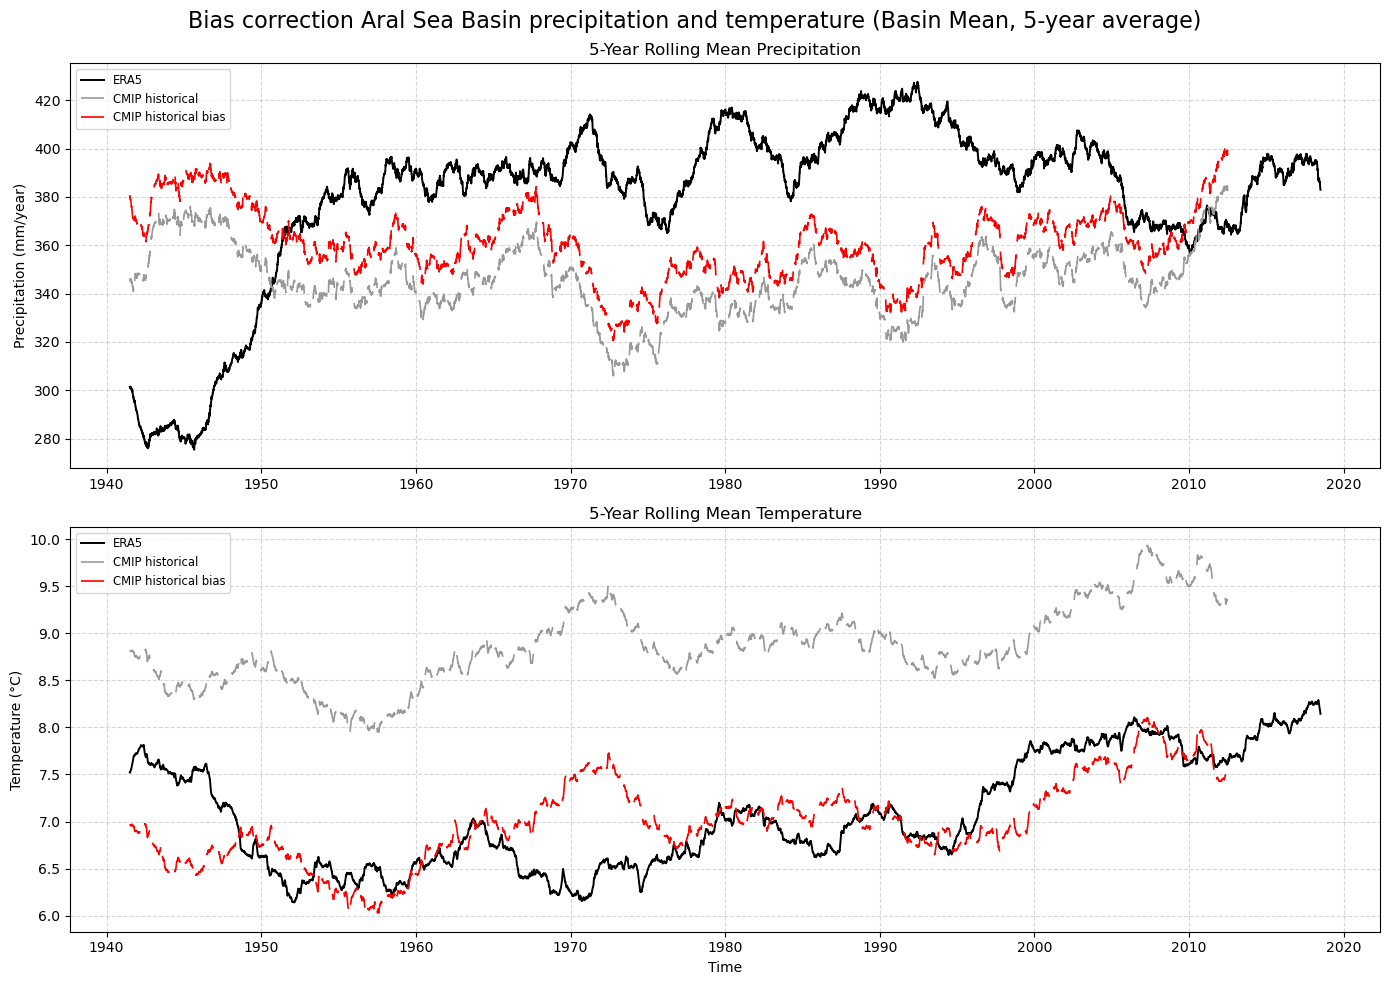

In [43]:
import matplotlib.pyplot as plt

def pick_var(ds, preferred):
    return preferred if preferred in ds.data_vars else list(ds.data_vars)[0]

def basin_daily_series(ds, var_name):
    da = ds[var_name]
    spatial_dims = [d for d in da.dims if d != "time"]
    if spatial_dims:
        da = da.mean(dim=spatial_dims)
    return da

experiments = {
    "ERA5": {
        "pr_ds": load_precip,
        "tas_ds": load_temp,
        "color": "black",
        "linestyle": "-",
        "linewidth": 1.4,
    },
    "CMIP historical": {
        "pr_ds": load_cmip_pr,
        "tas_ds": load_cmip_tas,
        "color": "0.6",
        "linestyle" : (0, (16,8)),
        "linewidth": 1.2,
    },
    "CMIP historical bias": {
        "pr_ds": load_cmip_hist_bias_pr,
        "tas_ds": load_cmip_hist_bias_tas,
        "color": "red",
        "linestyle" : (0, (16,8)),
        "linewidth": 1.2,
    },
    # "CMIP SSP126 corrected": {
    #     "pr_ds": load_cmip_future_pr_ssp126,
    #     "tas_ds": load_cmip_future_tas_ssp126,
    #     "color": "tab:green",
    #     "linestyle": "-",
    #     "linewidth": 1.4,
    # },
    # "CMIP SSP245 corrected": {
    #     "pr_ds": load_cmip_future_pr,
    #     "tas_ds": load_cmip_future_tas,
    #     "color": "tab:blue",
    #     "linestyle": "-",
    #     "linewidth": 1.4,
    # },
    # "CMIP SSP585 corrected": {
    #     "pr_ds": load_cmip_future_pr_ssp585,
    #     "tas_ds": load_cmip_future_tas_ssp585,
    #     "color": "tab:orange",
    #     "linestyle": "-",
    #     "linewidth": 1.4,
    # },
    # "CMIP SSP126 Original": {
    #     "pr_ds": load_cmip_future_pr_ssp126_original,
    #     "tas_ds": load_cmip_future_tas_ssp126_original,
    #     "color": "#a1d99b",
    #     #"linestyle": "-.",
    #     "linestyle" : (0, (16,8)),
    #     "linewidth": 1.2,
    # },
    # "CMIP SSP245 Original": {
    #     "pr_ds": load_cmip_future_pr_original,
    #     "tas_ds": load_cmip_future_tas_original,
    #     "color": "#9ecae1",
    #     "linestyle" : (0, (16,8)),
    #     "linewidth": 1.2,
    # },
    # "CMIP SSP585 Original": {
    #     "pr_ds": load_cmip_future_pr_ssp585_original,
    #     "tas_ds": load_cmip_future_tas_ssp585_original,
    #     "color": "#fdd0a2",
    #     "linestyle" : (0, (16,8)),
    #     "linewidth": 1.2,
    # }

}

# Build basin-mean daily series with unit conversions.
pr_daily_mm = {}
tas_daily_c = {}
for name, cfg in experiments.items():
    pr_var = pick_var(cfg["pr_ds"], "pr")
    tas_var = pick_var(cfg["tas_ds"], "tas")
    pr_daily_mm[name] = basin_daily_series(cfg["pr_ds"], pr_var) * 1000.0
    tas_daily_c[name] = basin_daily_series(cfg["tas_ds"], tas_var) - 273.15

# Rolling statistics:
# - precipitation: rolling mean daily precipitation, then scaled to mm/year
# - temperature: rolling mean in C
window_years = 5
window_days = window_years * 365

# For large rolling windows, rechunking time can reduce dask overhead.
roll_chunk_days = max(window_days * 2, 365)
for name in experiments:
    pr_daily_mm[name] = pr_daily_mm[name].chunk({"time": roll_chunk_days})
    tas_daily_c[name] = tas_daily_c[name].chunk({"time": roll_chunk_days})

pr_roll_mm_per_year = {
    name: da.rolling(time=window_days, center=True).mean() * 365.0
    for name, da in pr_daily_mm.items()
}
tas_roll_c = {
    name: da.rolling(time=window_days, center=True).mean()
    for name, da in tas_daily_c.items()
}

# # Keep legacy variable names available for downstream cells.
# era5_pr_roll_mm_per_year = pr_roll_mm_per_year["ERA5"]
# cmip_pr_roll_mm_per_year = pr_roll_mm_per_year["CMIP historical"]
# cmip_future_pr_roll_mm_per_year_ssp126 = pr_roll_mm_per_year["CMIP SSP126 corrected"]
# cmip_future_pr_roll_mm_per_year = pr_roll_mm_per_year["CMIP SSP245 corrected"]
# cmip_future_pr_roll_mm_per_year_ssp585 = pr_roll_mm_per_year["CMIP SSP585 corrected"]

# era5_tas_roll_c = tas_roll_c["ERA5"]
# cmip_tas_roll_c = tas_roll_c["CMIP historical"]
# cmip_future_tas_roll_c_ssp126 = tas_roll_c["CMIP SSP126 corrected"]
# cmip_future_tas_roll_c = tas_roll_c["CMIP SSP245 corrected"]
# cmip_future_tas_roll_c_ssp585 = tas_roll_c["CMIP SSP585 corrected"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

for name, cfg in experiments.items():
    pr_series = pr_roll_mm_per_year[name].compute()
    ax1.plot(
        pr_series["time"],
        pr_series,
        color=cfg["color"],
        linewidth=cfg["linewidth"],
        linestyle=cfg["linestyle"],
        label=f"{name}", # {window_years}-year rolling precip (mm/year)",
    )

ax1.set_ylabel("Precipitation (mm/year)")
ax1.set_title(f"{window_years}-Year Rolling Mean Precipitation")
ax1.legend(loc="upper left", fontsize="small")
ax1.grid(linestyle='--', alpha=0.5)

for name, cfg in experiments.items():
    tas_series = tas_roll_c[name].compute()
    ax2.plot(
        tas_series["time"],
        tas_series,
        color=cfg["color"],
        linewidth=cfg["linewidth"],
        linestyle=cfg["linestyle"],
        label=f"{name}", # {window_years}-year rolling temperature (C)",
    )

ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title(f"{window_years}-Year Rolling Mean Temperature")
ax2.legend(loc="upper left", fontsize="small")
ax2.grid(linestyle='--', alpha=0.5)

suptitle = f"Bias correction Aral Sea Basin precipitation and temperature (Basin Mean, {window_years}-year average)"

fig.suptitle(suptitle, fontsize=16)
plt.tight_layout()
plt.show()

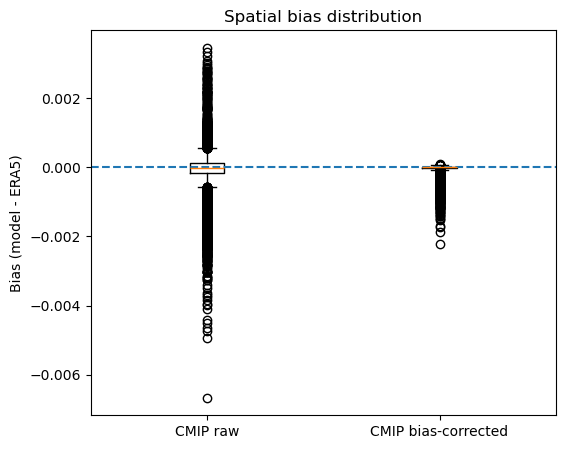

In [14]:
import numpy as np
import matplotlib.pyplot as plt

var = "pr"  # or tas

era = load_precip[var]  # or load_temp[var]
cmip = load_cmip_pr[var]
cmip_bc = load_cmip_hist_bias_pr[var]

# align (important!)
era, cmip = xr.align(era, cmip)
era, cmip_bc = xr.align(era, cmip_bc)

# spatial mean over time (or pick one season/year)
era_mean = era.mean("time")
cmip_mean = cmip.mean("time")
cmip_bc_mean = cmip_bc.mean("time")

# error fields
err_raw = (cmip_mean - era_mean).values.flatten()
err_bc  = (cmip_bc_mean - era_mean).values.flatten()

plt.figure(figsize=(6,5))

plt.boxplot([err_raw, err_bc],
            labels=["CMIP raw", "CMIP bias-corrected"])

plt.axhline(0, linestyle="--")
plt.ylabel("Bias (model - ERA5)")
plt.title("Spatial bias distribution")
plt.show()

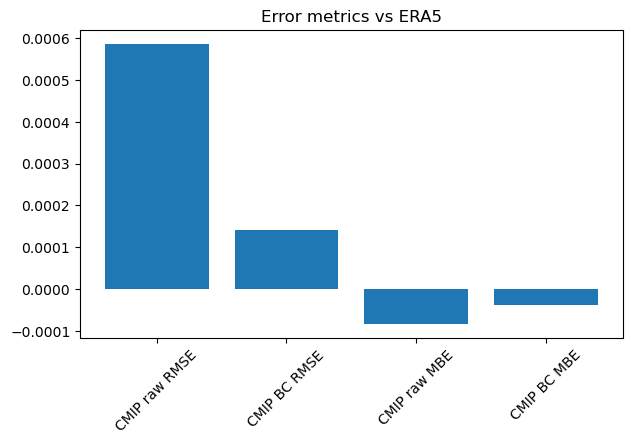

In [16]:
def rmse(a, b):
    return np.sqrt(((a - b) ** 2).mean()).compute()

def mbe(a, b):
    return (a - b).mean().compute()

metrics = {
    "CMIP raw RMSE": rmse(cmip_mean, era_mean).item(),
    "CMIP BC RMSE": rmse(cmip_bc_mean, era_mean).item(),
    "CMIP raw MBE": mbe(cmip_mean, era_mean).item(),
    "CMIP BC MBE": mbe(cmip_bc_mean, era_mean).item(),
}

plt.figure(figsize=(7,4))
plt.bar(metrics.keys(), metrics.values())
plt.xticks(rotation=45)
plt.title("Error metrics vs ERA5")
plt.show()

In [24]:
def yearly_precip(ds, var="pr"):
    da = ds[var]
    spatial = [d for d in da.dims if d != "time"]

    if spatial:
        da = da.mean(dim=spatial)

    return da.resample(time="1YS").sum()*1000

In [25]:
def yearly_temp(ds, var="tas"):
    da = ds[var]
    spatial = [d for d in da.dims if d != "time"]

    if spatial:
        da = da.mean(dim=spatial)

    return da.resample(time="1YS").mean()

In [37]:
def select_period(da):
    return da.sel(time=slice("1940-01-01", "2014-12-31"))

In [38]:
def stats(da):
    return {
        "mean": float(da.mean().compute()),
        "std": float(da.std().compute())
    }

In [39]:
datasets = {
    "ERA5": load_precip,
    "CMIP raw": load_cmip_pr,
    "CMIP bias corrected": load_cmip_hist_bias_pr,
}

results_pr = {}

for name, ds in datasets.items():
    pr_year = yearly_precip(ds)
    pr_year = select_period(pr_year)
    results_pr[name] = stats(pr_year)

In [40]:
datasets_tas = {
    "ERA5": load_temp,
    "CMIP raw": load_cmip_tas,
    "CMIP bias corrected": load_cmip_hist_bias_tas,
}

results_tas = {}

for name, ds in datasets_tas.items():
    tas_year = yearly_temp(ds)
    tas_year = select_period(tas_year)
    results_tas[name] = stats(tas_year)

In [41]:
print("PRECIPITATION (1940–2014)")
for k, v in results_pr.items():
    print(k, v)

print("\nTEMPERATURE (1940–2014)")
for k, v in results_tas.items():
    print(k, v)

PRECIPITATION (1940–2014)
ERA5 {'mean': 377.06610107421875, 'std': 45.62278366088867}
CMIP raw {'mean': 346.6556701660156, 'std': 36.63039016723633}
CMIP bias corrected {'mean': 361.70513916015625, 'std': 38.02301025390625}

TEMPERATURE (1940–2014)
ERA5 {'mean': 280.17388916015625, 'std': 0.7426545023918152}
CMIP raw {'mean': 282.0345153808594, 'std': 0.6358973383903503}
CMIP bias corrected {'mean': 280.1748046875, 'std': 0.6655605435371399}


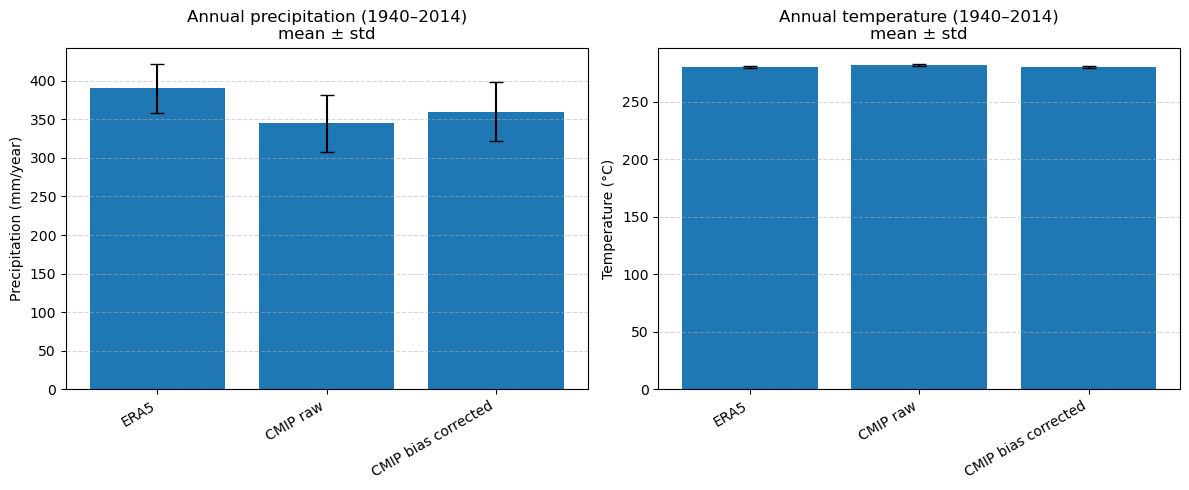

In [36]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(results_pr.keys())

# --- Precipitation ---
pr_mean = [results_pr[k]["mean"] for k in labels]
pr_std  = [results_pr[k]["std"] for k in labels]

# --- Temperature ---
tas_mean = [results_tas[k]["mean"] for k in labels]
tas_std  = [results_tas[k]["std"] for k in labels]

x = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# -------------------
# Precipitation
# -------------------
ax1.bar(x, pr_mean, yerr=pr_std, capsize=5)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha="right")
ax1.set_ylabel("Precipitation (mm/year)")
ax1.set_title("Annual precipitation (1940–2014)\nmean ± std")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# -------------------
# Temperature
# -------------------
ax2.bar(x, tas_mean, yerr=tas_std, capsize=5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=30, ha="right")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title("Annual temperature (1940–2014)\nmean ± std")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

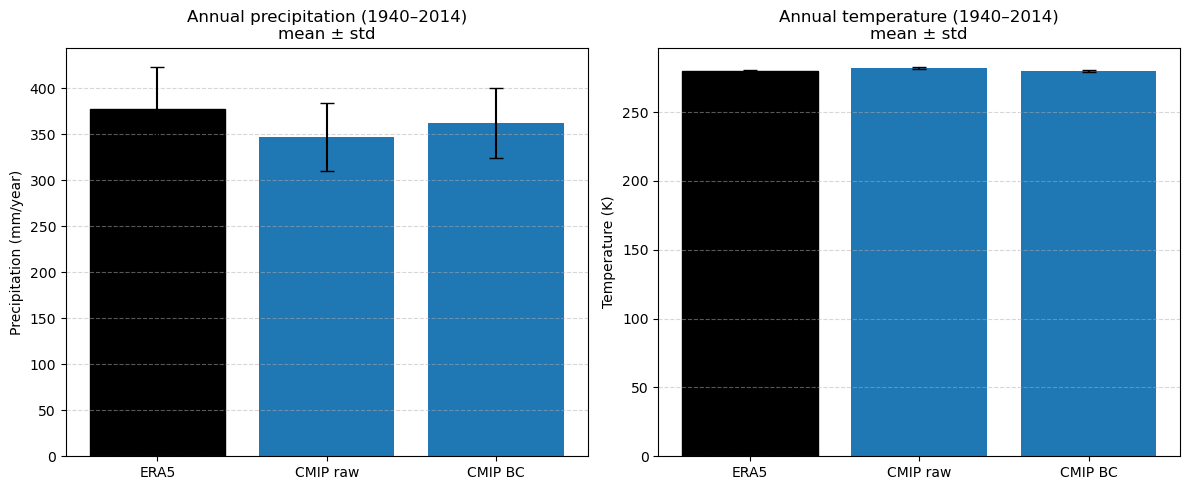

In [42]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["ERA5", "CMIP raw", "CMIP BC"]

# Precip
pr_mean = [377.066, 346.656, 361.705]
pr_std  = [45.623, 36.630, 38.023]

# Temp
tas_mean = [280.174, 282.035, 280.175]
tas_std  = [0.743, 0.636, 0.666]

x = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ---------------- PRECIP ----------------
ax1.bar(x, pr_mean, yerr=pr_std, capsize=5)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Precipitation (mm/year)")
ax1.set_title("Annual precipitation (1940–2014)\nmean ± std")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# highlight ERA5
ax1.get_children()[0].set_color("black")

# ---------------- TEMP ----------------
ax2.bar(x, tas_mean, yerr=tas_std, capsize=5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Temperature (K)")
ax2.set_title("Annual temperature (1940–2014)\nmean ± std")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

ax2.get_children()[0].set_color("black")

plt.tight_layout()
plt.show()